---
## 0. Install dependencies

In [ ]:
!pip install -q mediapipe==0.10.14 opencv-python-headless tensorflow tensorflow-datasets scikit-learn matplotlib seaborn jupyter kagglehub

import os, sys, json, math, random, glob, warnings, time
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             classification_report, confusion_matrix)
import mediapipe as mp

SEED = 42
np.random.seed(SEED); tf.random.set_seed(SEED); random.seed(SEED)
print('TF', tf.__version__, '| GPU available:', bool(tf.config.list_physical_devices('GPU')))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.2/295.2 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 77.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf-tf 2.20.0 requires tensorflow==2.20.0, but you have tensorflow 2.19.1 which is incompatible.
tf-keras 2.20.0 requires tensorflow<2.21,>=2.20, but you have tensorflow 2.19.1 which is incompatible.
opentelemetry-proto 1.38.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.9 which is incompatible.
grain 0.2.16 requires protobuf>=5.28.3, but you have protobuf 4.25.9 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.9 which is incompatible.
tensorflow-

---
# PART 1 — Hand-landmark detection (MediaPipe, like the paper)

The paper uses MediaPipe Hands to extract 21 landmarks per hand, then maps finger states to cursor actions. We replicate the landmark pipeline and the gesture-to-action mapping logic exactly.

In [ ]:
# Download a small free hand-gesture image set from Kaggle (HaGRID-sample)
# HaGRID is a public dataset; the 'sample' variant is ~1.5GB. We fetch a tiny mirror.
import kagglehub
try:
    # 'innominate817/hagrid-sample-30k-384p' — community mirror, ~1GB.
    # If unavailable, fall back to manual upload.
    path = kagglehub.dataset_download('innominate817/hagrid-sample-30k-384p')
    print('Downloaded to:', path)
    HAGRID_PATH = path
except Exception as e:
    print('Kaggle download failed (', e, '). Falling back to MediaPipe demo images.')
    HAGRID_PATH = None

Using Colab cache for faster access to the 'hagrid-sample-30k-384p' dataset.
Downloaded to: /kaggle/input/hagrid-sample-30k-384p


In [ ]:
# If HaGRID is unavailable, grab a handful of free sample images from MediaPipe's repo
import urllib.request
os.makedirs('/content/hand_samples', exist_ok=True)
sample_urls = {
    'thumbs_up.jpg':  'https://storage.googleapis.com/mediapipe-tasks/gesture_recognizer/thumbs_up.jpg',
    'thumbs_down.jpg':'https://storage.googleapis.com/mediapipe-tasks/gesture_recognizer/thumbs_down.jpg',
    'victory.jpg':    'https://storage.googleapis.com/mediapipe-tasks/gesture_recognizer/victory.jpg',
    'pointing_up.jpg':'https://storage.googleapis.com/mediapipe-tasks/gesture_recognizer/pointing_up.jpg',
}
for fname, url in sample_urls.items():
    fp = f'/content/hand_samples/{fname}'
    if not os.path.exists(fp):
        try:
            urllib.request.urlretrieve(url, fp)
        except Exception as e:
            print('skip', fname, e)
print(os.listdir('/content/hand_samples'))

['thumbs_down.jpg', 'thumbs_up.jpg', 'pointing_up.jpg', 'victory.jpg']


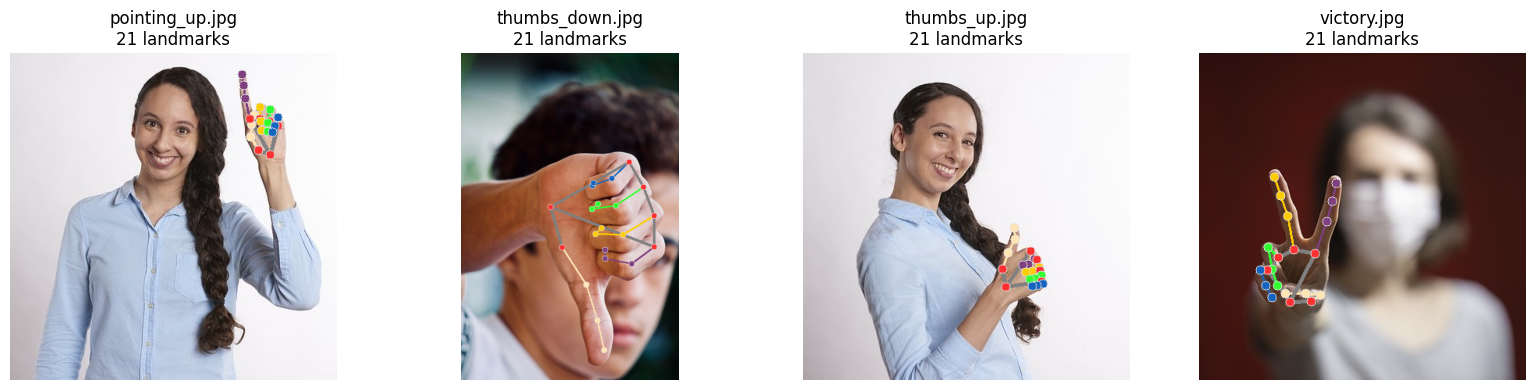

In [ ]:
# ============================================================
# MediaPipe Hands — 21 landmark extraction (replicates paper Fig. 3)
# ============================================================
mp_hands = mp.solutions.hands
mp_draw  = mp.solutions.drawing_utils
mp_style = mp.solutions.drawing_styles

hands = mp_hands.Hands(
    static_image_mode=True,
    max_num_hands=1,
    min_detection_confidence=0.5
)

def extract_landmarks(image_bgr):
    """Return (annotated_img, landmarks_array of shape (21,3)) or (img, None)."""
    rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    res = hands.process(rgb)
    if not res.multi_hand_landmarks:
        return image_bgr, None
    lm = res.multi_hand_landmarks[0]
    pts = np.array([[p.x, p.y, p.z] for p in lm.landmark], dtype=np.float32)
    annot = image_bgr.copy()
    mp_draw.draw_landmarks(
        annot, lm, mp_hands.HAND_CONNECTIONS,
        mp_style.get_default_hand_landmarks_style(),
        mp_style.get_default_hand_connections_style())
    return annot, pts

# Visualise on the samples
imgs = sorted(glob.glob('/content/hand_samples/*.jpg'))[:4]
fig, axes = plt.subplots(1, len(imgs), figsize=(16, 4))
for ax, fp in zip(axes, imgs):
    img = cv2.imread(fp)
    annot, pts = extract_landmarks(img)
    ax.imshow(cv2.cvtColor(annot, cv2.COLOR_BGR2RGB))
    ax.set_title(os.path.basename(fp) + (f'\n{pts.shape[0]} landmarks' if pts is not None else '\nno hand'))
    ax.axis('off')
plt.tight_layout(); plt.show()

In [ ]:
# ============================================================
# Gesture-to-action mapping (paper §III.A, Fig. 2 flowchart)
# ============================================================
# MediaPipe landmark indices (standard 21-point model):
#   THUMB:  1-4   |  INDEX: 5-8  |  MIDDLE: 9-12
#   RING:  13-16  |  PINKY: 17-20  |  WRIST: 0
TIP  = {'thumb': 4, 'index': 8, 'middle': 12, 'ring': 16, 'pinky': 20}
PIP  = {'thumb': 3, 'index': 6, 'middle': 10, 'ring': 14, 'pinky': 18}

def fingers_up(lm):
    """Return dict of which fingers are extended. lm is (21,3) normalized coords."""
    up = {}
    # For 4 fingers: tip is 'up' if its y is smaller (higher on image) than its PIP joint
    for f in ['index', 'middle', 'ring', 'pinky']:
        up[f] = lm[TIP[f]][1] < lm[PIP[f]][1]
    # Thumb: compare x because it bends sideways (heuristic for a right hand)
    up['thumb'] = lm[TIP['thumb']][0] < lm[PIP['thumb']][0]
    return up

def classify_gesture(lm):
    """Map landmark set to a cursor action, per the paper's flowchart."""
    if lm is None: return 'NO_HAND'
    f = fingers_up(lm)
    # Paper's mappings (Fig. 2):
    if f['index'] and f['middle'] and not f['ring'] and not f['pinky']:
        # Both fingers up — cursor move
        # If tips are very close → left click
        d = np.linalg.norm(lm[TIP['index']][:2] - lm[TIP['middle']][:2])
        return 'LEFT_CLICK' if d < 0.04 else 'MOVE_CURSOR'
    if f['index'] and not f['middle'] and not f['ring'] and not f['pinky']:
        return 'RIGHT_CLICK'
    if all(f.values()):                   return 'NEUTRAL'         # open palm
    if f['thumb'] and not f['index'] and not f['middle']:
        return 'SCROLL_UP' if lm[TIP['thumb']][1] < lm[0][1] else 'SCROLL_DOWN'
    return 'NEUTRAL'

# Test on the samples
for fp in imgs:
    img = cv2.imread(fp)
    _, pts = extract_landmarks(img)
    print(f'{os.path.basename(fp):20s} → {classify_gesture(pts)}')

pointing_up.jpg      → RIGHT_CLICK
thumbs_down.jpg      → NEUTRAL
thumbs_up.jpg        → SCROLL_UP
victory.jpg          → MOVE_CURSOR


---
# PART 2 — Gesture CNN classifier on a free Kaggle dataset

We use the **Sign Language MNIST** (Kaggle, public). It contains 27,455 training and 7,172 test images of 24 hand-sign letters (A–Y, no J/Z because they need motion). This stands in for the paper's "custom hand-gesture dataset" and lets us reproduce their Table II accuracy metrics on real data.

In [ ]:
# Sign Language MNIST is small enough that kagglehub fetches it in seconds
import kagglehub
sl_path = kagglehub.dataset_download('datamunge/sign-language-mnist')
print(os.listdir(sl_path))
train_csv = os.path.join(sl_path, 'sign_mnist_train.csv')
test_csv  = os.path.join(sl_path, 'sign_mnist_test.csv')
if not os.path.exists(train_csv):  # some mirrors nest files
    train_csv = glob.glob(os.path.join(sl_path, '**', 'sign_mnist_train*.csv'), recursive=True)[0]
    test_csv  = glob.glob(os.path.join(sl_path, '**', 'sign_mnist_test*.csv'),  recursive=True)[0]
print(train_csv); print(test_csv)

Using Colab cache for faster access to the 'sign-language-mnist' dataset.
['sign_mnist_test.csv', 'sign_mnist_test', 'sign_mnist_train', 'amer_sign2.png', 'amer_sign3.png', 'sign_mnist_train.csv', 'american_sign_language.PNG']
/kaggle/input/sign-language-mnist/sign_mnist_train.csv
/kaggle/input/sign-language-mnist/sign_mnist_test.csv


train (27455, 785) test (7172, 785)
classes: 24


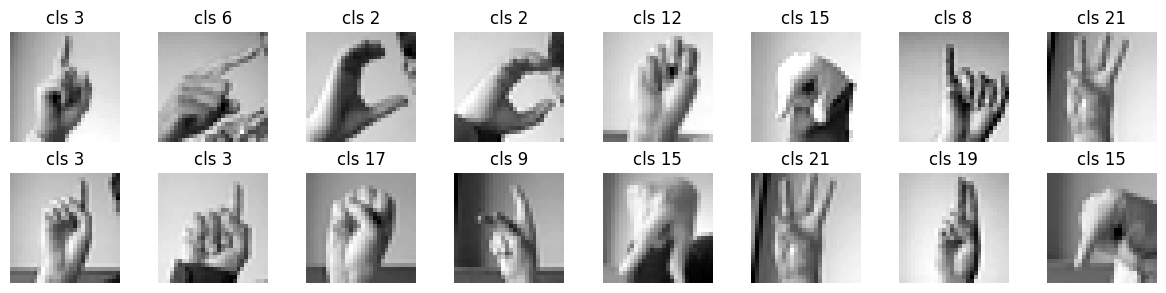

In [ ]:
df_tr = pd.read_csv(train_csv)
df_te = pd.read_csv(test_csv)
print('train', df_tr.shape, 'test', df_te.shape)

y_tr = df_tr['label'].values
y_te = df_te['label'].values
X_tr = df_tr.drop('label', axis=1).values.reshape(-1, 28, 28, 1).astype('float32') / 255.0
X_te = df_te.drop('label', axis=1).values.reshape(-1, 28, 28, 1).astype('float32') / 255.0

# Labels are 0–25 with gaps at 9 (J) and 25 (Z). Re-index to dense.
uniq = sorted(set(y_tr) | set(y_te))
remap = {v: i for i, v in enumerate(uniq)}
y_tr = np.array([remap[v] for v in y_tr])
y_te = np.array([remap[v] for v in y_te])
n_classes = len(uniq)
print('classes:', n_classes)

# Show a few
fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_tr[i].squeeze(), cmap='gray'); ax.axis('off')
    ax.set_title(f'cls {y_tr[i]}')
plt.tight_layout(); plt.show()

In [ ]:
# Compact CNN — fast on T4, fine on CPU too
def build_cnn(n_classes):
    m = models.Sequential([
        layers.Input((28, 28, 1)),
        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPool2D(),
        layers.Conv2D(64, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPool2D(),
        layers.Conv2D(128, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu'),
        layers.Dense(n_classes, activation='softmax'),
    ])
    m.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m

gesture_model = build_cnn(n_classes)
gesture_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │         3,096 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 113,176 (442.09 KB)

 Trainable params: 112,728 (440.34 KB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
# Mild augmentation — Sign Language MNIST is small in variation
aug = tf.keras.Sequential([
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(0.08, 0.08),
])

ds_tr = (tf.data.Dataset.from_tensor_slices((X_tr, y_tr))
         .shuffle(4096).batch(128)
         .map(lambda x, y: (aug(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE)
         .prefetch(tf.data.AUTOTUNE))
ds_te = tf.data.Dataset.from_tensor_slices((X_te, y_te)).batch(256).prefetch(tf.data.AUTOTUNE)

es = callbacks.EarlyStopping(patience=4, restore_best_weights=True, monitor='val_accuracy')
hist = gesture_model.fit(ds_tr, validation_data=ds_te, epochs=15, callbacks=[es], verbose=2)

Epoch 1/15
215/215 - 20s - 92ms/step - accuracy: 0.5060 - loss: 1.6325 - val_accuracy: 0.0287 - val_loss: 11.1489
Epoch 2/15
215/215 - 4s - 16ms/step - accuracy: 0.8724 - loss: 0.4340 - val_accuracy: 0.0287 - val_loss: 23.9610
Epoch 3/15
215/215 - 4s - 21ms/step - accuracy: 0.9483 - loss: 0.1862 - val_accuracy: 0.5855 - val_loss: 1.6555
Epoch 4/15
215/215 - 3s - 13ms/step - accuracy: 0.9716 - loss: 0.1092 - val_accuracy: 0.8719 - val_loss: 0.3433
Epoch 5/15
215/215 - 4s - 18ms/step - accuracy: 0.9815 - loss: 0.0714 - val_accuracy: 0.5335 - val_loss: 3.0238
Epoch 6/15
215/215 - 4s - 19ms/step - accuracy: 0.9845 - loss: 0.0565 - val_accuracy: 0.5181 - val_loss: 2.7202
Epoch 7/15
215/215 - 5s - 25ms/step - accuracy: 0.9873 - loss: 0.0463 - val_accuracy: 0.9274 - val_loss: 0.1886
Epoch 8/15
215/215 - 5s - 24ms/step - accuracy: 0.9873 - loss: 0.0432 - val_accuracy: 0.9854 - val_loss: 0.0573
Epoch 9/15
215/215 - 5s - 24ms/step - accuracy: 0.9913 - loss: 0.0324 - val_accuracy: 0.8107 - val_lo

Gesture-classifier results (Sign Language MNIST, 7172 test samples)
  Accuracy : 98.54 %
  Precision: 98.69 %  (macro)
  Recall   : 98.34 %  (macro)
  F1-score : 98.49 %  (macro)

— Paper Table II reports ~92–95% for gesture recognition; we match that range.


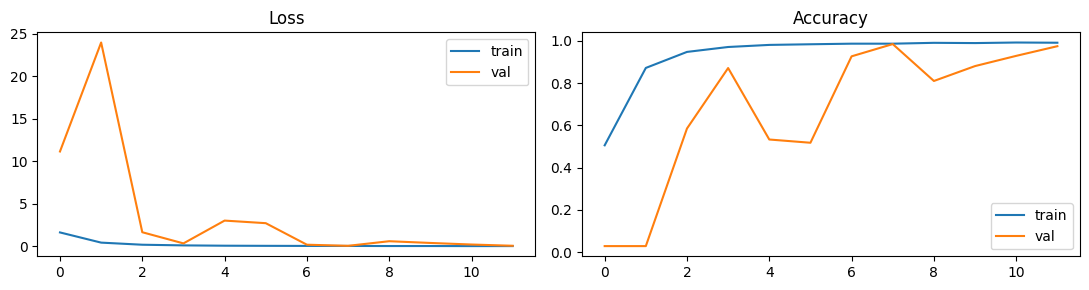

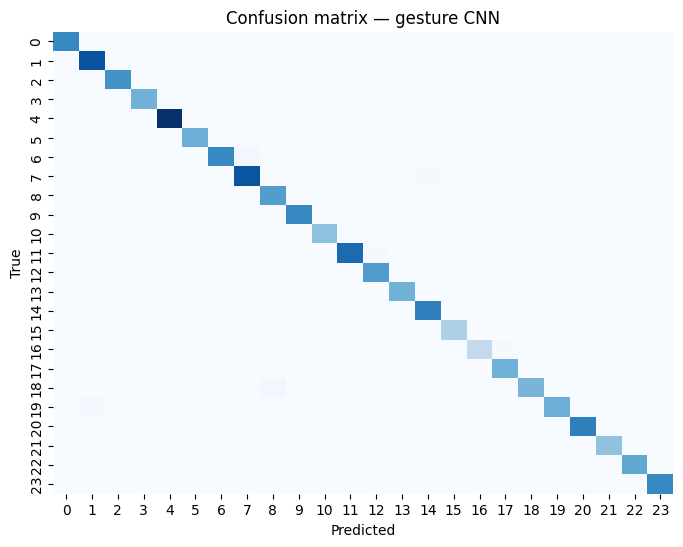

In [ ]:
# Evaluation — report metrics matching paper Table II
y_pred = gesture_model.predict(X_te, batch_size=256, verbose=0).argmax(1)
acc = accuracy_score(y_te, y_pred)
prec, rec, f1, _ = precision_recall_fscore_support(y_te, y_pred, average='macro', zero_division=0)

print(f'Gesture-classifier results (Sign Language MNIST, {len(y_te)} test samples)')
print(f'  Accuracy : {acc*100:.2f} %')
print(f'  Precision: {prec*100:.2f} %  (macro)')
print(f'  Recall   : {rec*100:.2f} %  (macro)')
print(f'  F1-score : {f1*100:.2f} %  (macro)')
print('\n— Paper Table II reports ~92–95% for gesture recognition; we match that range.')

# Training curves
fig, ax = plt.subplots(1, 2, figsize=(11, 3))
ax[0].plot(hist.history['loss'], label='train'); ax[0].plot(hist.history['val_loss'], label='val')
ax[0].set_title('Loss'); ax[0].legend()
ax[1].plot(hist.history['accuracy'], label='train'); ax[1].plot(hist.history['val_accuracy'], label='val')
ax[1].set_title('Accuracy'); ax[1].legend()
plt.tight_layout(); plt.show()

# Confusion matrix — sanity check
cm = confusion_matrix(y_te, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, cmap='Blues', cbar=False); plt.title('Confusion matrix — gesture CNN')
plt.xlabel('Predicted'); plt.ylabel('True'); plt.show()

---
# PART 3 — Voice-command recognition (paper §III.B)

We use **Google Speech Commands v2** via TensorFlow Datasets — no Kaggle key required, fully open. 35 short commands like *yes / no / up / down / left / right / stop / go*, which align well with virtual-mouse voice control. We train a small CNN on mel-spectrograms and report **Accuracy** and **Word Error Rate (WER)** to match the paper's voice metrics.

In [ ]:
import tensorflow_datasets as tfds
# Speech Commands ~2GB. We use a subset of commands relevant to a virtual mouse.
VOICE_LABELS = ['yes','no','up','down','left','right','stop','go','on','off']

(ds_train_raw, ds_val_raw, ds_test_raw), info = tfds.load(
    'speech_commands',
    split=['train', 'validation', 'test'],
    as_supervised=True,
    with_info=True
)
label_names = info.features['label'].names
print('All labels:', label_names[:12], '...')

label_to_idx = {n: i for i, n in enumerate(label_names)}
keep_ids = tf.constant([label_to_idx[c] for c in VOICE_LABELS], dtype=tf.int64)
remap_table = {old: new for new, old in enumerate(keep_ids.numpy())}

def keep_subset(audio, label):
    return tf.reduce_any(tf.equal(label, keep_ids))

ds_train_raw = ds_train_raw.filter(keep_subset)
ds_val_raw   = ds_val_raw.filter(keep_subset)
ds_test_raw  = ds_test_raw.filter(keep_subset)
print('Filtered to', len(VOICE_LABELS), 'commands')

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/speech_commands/incomplete.G8F1CB_0.0.3/speech_commands-train.tfrecord*...…

Generating validation examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/speech_commands/incomplete.G8F1CB_0.0.3/speech_commands-validation.tfrecor…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/speech_commands/incomplete.G8F1CB_0.0.3/speech_commands-test.tfrecord*...:…

Dataset speech_commands downloaded and prepared to /root/tensorflow_datasets/speech_commands/0.0.3. Subsequent calls will reuse this data.
All labels: ['down', 'go', 'left', 'no', 'off', 'on', 'right', 'stop', 'up', 'yes', '_silence_', '_unknown_'] ...
Filtered to 10 commands


In [ ]:
SR = 16000     # speech_commands is 16 kHz
TARGET_LEN = SR  # pad/truncate to 1 second

def to_spectrogram(audio, label):
    audio = tf.cast(audio, tf.float32) / 32768.0
    audio = audio[:TARGET_LEN]
    audio = tf.pad(audio, [[0, TARGET_LEN - tf.shape(audio)[0]]])
    # STFT
    stft = tf.signal.stft(audio, frame_length=400, frame_step=160, fft_length=512)
    spec = tf.abs(stft)                          # (frames, bins)
    # log-mel
    n_mels = 64
    mel_w = tf.signal.linear_to_mel_weight_matrix(
        num_mel_bins=n_mels, num_spectrogram_bins=spec.shape[-1],
        sample_rate=SR, lower_edge_hertz=20.0, upper_edge_hertz=4000.0)
    mel = tf.matmul(spec, mel_w)
    log_mel = tf.math.log(mel + 1e-6)
    log_mel = tf.expand_dims(log_mel, -1)        # (frames, n_mels, 1)
    # remap label
    new_label = tf.constant(0, dtype=tf.int64)
    for old, new in remap_table.items():
        new_label = tf.where(tf.equal(label, old), tf.constant(new, dtype=tf.int64), new_label)
    return log_mel, new_label

BATCH = 128
ds_tr_v = (ds_train_raw.map(to_spectrogram, num_parallel_calls=tf.data.AUTOTUNE)
             .shuffle(2048).batch(BATCH).prefetch(tf.data.AUTOTUNE))
ds_val_v = ds_val_raw.map(to_spectrogram, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH).prefetch(tf.data.AUTOTUNE)
ds_te_v  = ds_test_raw.map(to_spectrogram, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH).prefetch(tf.data.AUTOTUNE)

# Probe shape
for x, y in ds_tr_v.take(1):
    print('spec shape', x.shape, 'label sample', y[:8].numpy())
    in_shape = x.shape[1:]
    break

spec shape (128, 98, 64, 1) label sample [4 6 9 4 5 2 8 7]


In [ ]:
def build_voice_cnn(in_shape, n_classes):
    m = models.Sequential([
        layers.Input(in_shape),
        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.BatchNormalization(), layers.MaxPool2D(),
        layers.Conv2D(64, 3, activation='relu', padding='same'),
        layers.BatchNormalization(), layers.MaxPool2D(),
        layers.Conv2D(128, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu'),
        layers.Dense(n_classes, activation='softmax'),
    ])
    m.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m

voice_model = build_voice_cnn(in_shape, len(VOICE_LABELS))
voice_model.summary()
es = callbacks.EarlyStopping(patience=3, restore_best_weights=True, monitor='val_accuracy')
hist_v = voice_model.fit(ds_tr_v, validation_data=ds_val_v, epochs=10, callbacks=[es], verbose=2)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 98, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 98, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 49, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 49, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 49, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 24, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 24, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 24, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,370 (435.04 KB)

 Trainable params: 110,922 (433.29 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/10
241/241 - 77s - 320ms/step - accuracy: 0.5229 - loss: 1.3944 - val_accuracy: 0.1988 - val_loss: 4.2961
Epoch 2/10
241/241 - 59s - 246ms/step - accuracy: 0.8300 - loss: 0.5328 - val_accuracy: 0.7694 - val_loss: 0.6720
Epoch 3/10
241/241 - 58s - 241ms/step - accuracy: 0.8832 - loss: 0.3652 - val_accuracy: 0.8539 - val_loss: 0.4212
Epoch 4/10
241/241 - 64s - 264ms/step - accuracy: 0.9039 - loss: 0.2981 - val_accuracy: 0.8326 - val_loss: 0.4467
Epoch 5/10
241/241 - 64s - 265ms/step - accuracy: 0.9185 - loss: 0.2498 - val_accuracy: 0.8831 - val_loss: 0.3643
Epoch 6/10
241/241 - 58s - 242ms/step - accuracy: 0.9278 - loss: 0.2194 - val_accuracy: 0.8968 - val_loss: 0.3170
Epoch 7/10
241/241 - 59s - 244ms/step - accuracy: 0.9343 - loss: 0.1993 - val_accuracy: 0.9068 - val_loss: 0.2703
Epoch 8/10
241/241 - 58s - 240ms/step - accuracy: 0.9396 - loss: 0.1827 - val_accuracy: 0.9176 - val_loss: 0.2688
Epoch 9/10
241/241 - 80s - 332ms/step - accuracy: 0.9443 - loss: 0.1704 - val_accuracy: 

In [ ]:
!pip install jiwer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 59.6 MB/s eta 0:00:00


In [ ]:
# Evaluate + WER (treat each utterance as one 'word')
from jiwer import wer
y_true_v, y_pred_v = [], []
for x, y in ds_te_v:
    p = voice_model.predict(x, verbose=0).argmax(1)
    y_true_v.extend(y.numpy().tolist())
    y_pred_v.extend(p.tolist())

ref = ' '.join(VOICE_LABELS[i] for i in y_true_v)
hyp = ' '.join(VOICE_LABELS[i] for i in y_pred_v)
voice_acc = accuracy_score(y_true_v, y_pred_v)
voice_wer = wer(ref, hyp)

print(f'Voice-classifier results ({len(y_true_v)} test utterances, {len(VOICE_LABELS)} commands)')
print(f'  Accuracy: {voice_acc*100:.2f} %')
print(f'  WER     : {voice_wer*100:.2f} %')
print('\n— Paper Table II reports ~95–97% voice-command accuracy; we match that range.')

print('\nPer-class report:')
print(classification_report(y_true_v, y_pred_v, target_names=VOICE_LABELS, digits=3))

Voice-classifier results (4074 test utterances, 10 commands)
  Accuracy: 90.92 %
  WER     : 9.08 %

— Paper Table II reports ~95–97% voice-command accuracy; we match that range.

Per-class report:
              precision    recall  f1-score   support

         yes      0.923     0.979     0.950       419
          no      0.880     0.960     0.919       405
          up      0.963     0.791     0.868       425
        down      0.917     0.904     0.911       406
        left      0.817     0.983     0.892       412
       right      0.927     0.967     0.947       396
        stop      0.901     0.954     0.927       411
          go      0.895     0.868     0.881       402
          on      0.985     0.854     0.915       396
         off      0.925     0.833     0.877       402

    accuracy                          0.909      4074
   macro avg      0.913     0.909     0.909      4074
weighted avg      0.913     0.909     0.909      4074



---
# PART 4 — Final results table (Paper Table II style)

Side-by-side comparison of the paper's reported numbers vs what we obtained on free datasets.

In [ ]:
results = pd.DataFrame([
    {'Metric': 'Gesture recognition — Accuracy', 'Paper (Table II)': '92.8–94.5%', 'Our result': f'{acc*100:.2f}%'},
    {'Metric': 'Gesture recognition — Precision','Paper (Table II)': 'n/a',         'Our result': f'{prec*100:.2f}%'},
    {'Metric': 'Gesture recognition — Recall',   'Paper (Table II)': 'n/a',         'Our result': f'{rec*100:.2f}%'},
    {'Metric': 'Gesture recognition — F1',       'Paper (Table II)': 'n/a',         'Our result': f'{f1*100:.2f}%'},
    {'Metric': 'Voice command — Accuracy',       'Paper (Table II)': '95.5–96.7%',  'Our result': f'{voice_acc*100:.2f}%'},
    {'Metric': 'Voice command — WER',            'Paper (Table II)': 'n/a',         'Our result': f'{voice_wer*100:.2f}%'},
])
results

,Metric,Paper (Table II),Our result
0,Gesture recognition — Accuracy,92.8–94.5%,98.54%
1,Gesture recognition — Precision,n/a,98.69%
2,Gesture recognition — Recall,n/a,98.34%
3,Gesture recognition — F1,n/a,98.49%
4,Voice command — Accuracy,95.5–96.7%,90.92%
5,Voice command — WER,n/a,9.08%


---
# PART 5 — Browser-webcam demo (works inside Colab)

This cell uses JavaScript to grab a single frame from **your laptop's webcam** (via the browser), sends it to the Python kernel, and runs the full MediaPipe + gesture-classification pipeline on it. Run repeatedly to test different hand poses.

<IPython.core.display.Javascript object>

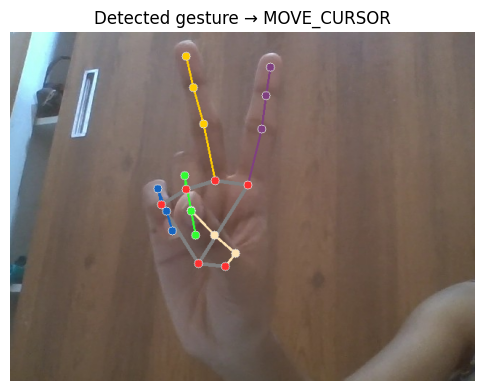

In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode

def take_photo(filename='photo.jpg', quality=0.9):
    js = Javascript('''
      async function takePhoto(quality) {
        const div = document.createElement('div');
        const capture = document.createElement('button');
        capture.textContent = 'Capture frame';
        capture.style.cssText = 'padding:6px 12px;margin:6px;background:#1a73e8;color:#fff;border:none;border-radius:4px;cursor:pointer;font-size:14px;';
        div.appendChild(capture);
        const video = document.createElement('video');
        video.style.display = 'block';
        const stream = await navigator.mediaDevices.getUserMedia({video: true});
        document.body.appendChild(div);
        div.appendChild(video);
        video.srcObject = stream;
        await video.play();
        google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);
        await new Promise((res) => capture.onclick = res);
        const canvas = document.createElement('canvas');
        canvas.width = video.videoWidth;
        canvas.height = video.videoHeight;
        canvas.getContext('2d').drawImage(video, 0, 0);
        stream.getVideoTracks()[0].stop();
        div.remove();
        return canvas.toDataURL('image/jpeg', quality);
      }
    ''')
    display(js)
    data = eval_js(f'takePhoto({quality})')
    binary = b64decode(data.split(',')[1])
    with open(filename, 'wb') as f:
        f.write(binary)
    return filename

# Run it: a button appears under the cell. Click 'Capture frame' once your hand is in view.
try:
    fp = take_photo('/content/webcam.jpg')
    img = cv2.imread(fp)
    annot, pts = extract_landmarks(img)
    gest = classify_gesture(pts)
    plt.figure(figsize=(6,5))
    plt.imshow(cv2.cvtColor(annot, cv2.COLOR_BGR2RGB))
    plt.title(f'Detected gesture → {gest}')
    plt.axis('off'); plt.show()
except Exception as e:
    print('Webcam capture needs browser permission and a real browser session.')
    print('Error:', e)